# Weather Australia - Exploratory Data Analysis

This notebook performs initial exploration of the weatherAUS.csv dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

## 1. Load Data

In [2]:
# Load dataset
df = pd.read_csv('../data/raw/weatherAUS.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (145460, 23)
Number of rows: 145,460
Number of columns: 23


In [3]:
# Display first few rows
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
# Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

## 2. Missing Values Analysis

In [5]:
# Calculate missing values
missing = pd.DataFrame({
    'Total Missing': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Total Missing'] > 0].sort_values('Total Missing', ascending=False)
print(missing)

               Total Missing  Percentage
Sunshine               69835       48.01
Evaporation            62790       43.17
Cloud3pm               59358       40.81
Cloud9am               55888       38.42
Pressure9am            15065       10.36
Pressure3pm            15028       10.33
WindDir9am             10566        7.26
WindGustDir            10326        7.10
WindGustSpeed          10263        7.06
Humidity3pm             4507        3.10
WindDir3pm              4228        2.91
Temp3pm                 3609        2.48
RainTomorrow            3267        2.25
Rainfall                3261        2.24
RainToday               3261        2.24
WindSpeed3pm            3062        2.11
Humidity9am             2654        1.82
Temp9am                 1767        1.21
WindSpeed9am            1767        1.21
MinTemp                 1485        1.02
MaxTemp                 1261        0.87


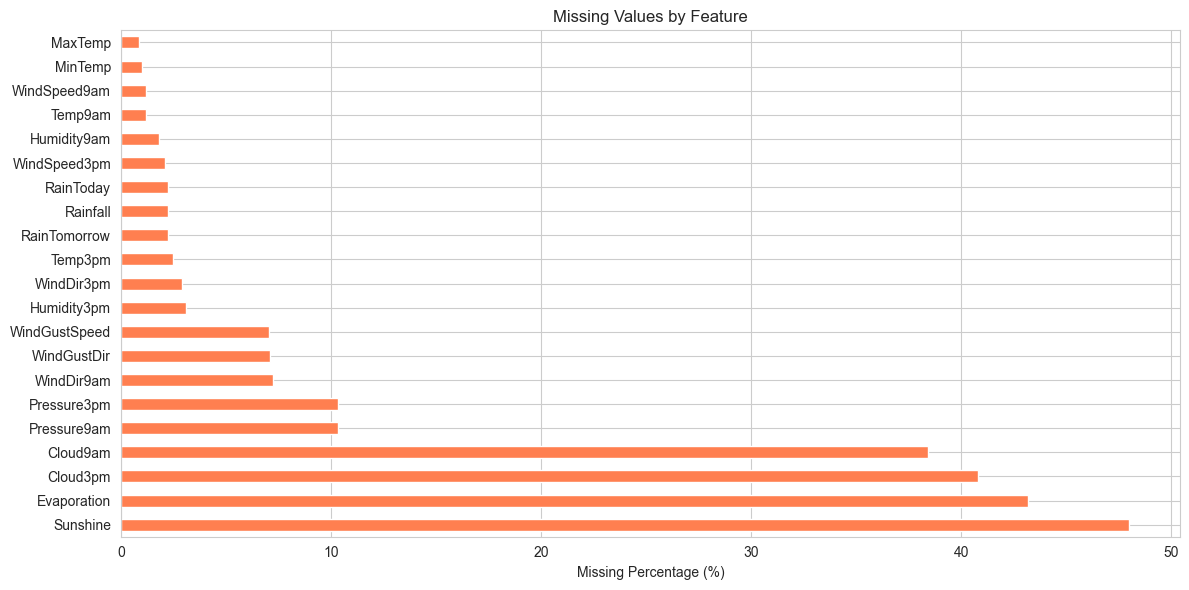

In [6]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing['Percentage'].plot(kind='barh', color='coral')
plt.xlabel('Missing Percentage (%)')
plt.title('Missing Values by Feature')
plt.tight_layout()
plt.show()

## 3. Target Variable Analysis

Target variable distribution:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

Percentage:
RainTomorrow
No     77.581878
Yes    22.418122
Name: proportion, dtype: float64


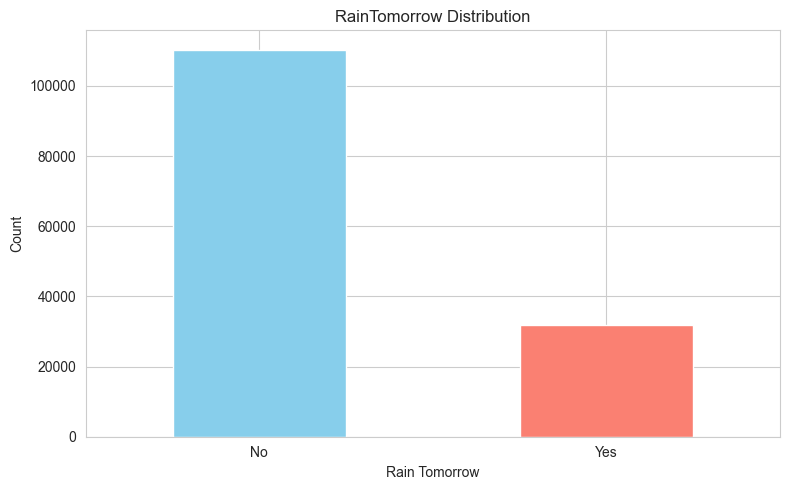

In [7]:
# Check if RainTomorrow exists (our target variable)
if 'RainTomorrow' in df.columns:
    print("Target variable distribution:")
    print(df['RainTomorrow'].value_counts())
    print("\nPercentage:")
    print(df['RainTomorrow'].value_counts(normalize=True) * 100)
    
    # Visualize target distribution
    plt.figure(figsize=(8, 5))
    df['RainTomorrow'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
    plt.title('RainTomorrow Distribution')
    plt.xlabel('Rain Tomorrow')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 4. Numerical Features Analysis

In [8]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

Numerical features (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [9]:
# Statistical summary
df[numerical_cols].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


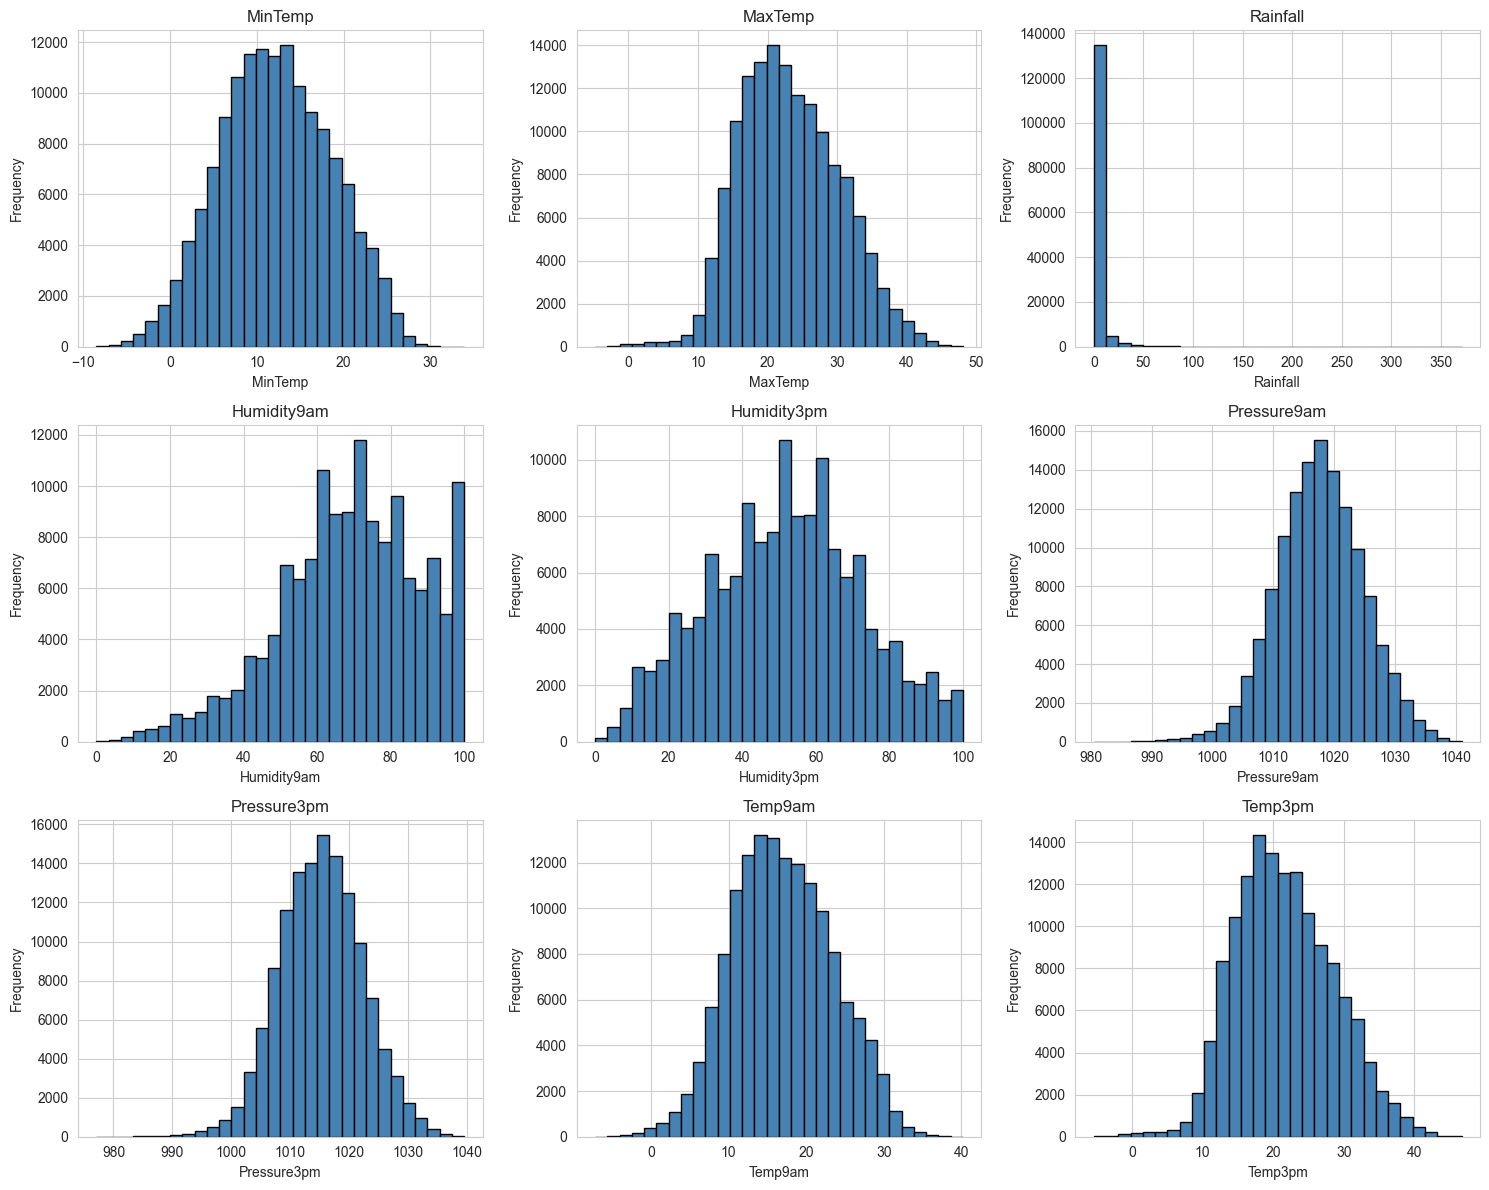

In [10]:
# Distribution of key numerical features
key_features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']
key_features = [col for col in key_features if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    if idx < len(axes):
        df[col].hist(bins=30, ax=axes[idx], color='steelblue', edgecolor='black')
        axes[idx].set_title(col)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

# Hide unused subplots
for idx in range(len(key_features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 5. Categorical Features Analysis

In [11]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Categorical features (7): ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [12]:
# Analyze categorical features
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


Date:
Date
2013-11-12    49
2014-09-01    49
2014-08-23    49
2014-08-24    49
2014-08-25    49
2014-08-26    49
2014-08-27    49
2014-08-28    49
2014-08-29    49
2014-08-30    49
Name: count, dtype: int64

Location:
Location
Canberra        3436
Sydney          3344
Darwin          3193
Melbourne       3193
Brisbane        3193
Adelaide        3193
Perth           3193
Hobart          3193
Albany          3040
MountGambier    3040
Name: count, dtype: int64

WindGustDir:
WindGustDir
W      9915
SE     9418
N      9313
SSE    9216
E      9181
S      9168
WSW    9069
SW     8967
SSW    8736
WNW    8252
Name: count, dtype: int64

WindDir9am:
WindDir9am
N      11758
SE      9287
E       9176
SSE     9112
NW      8749
S       8659
W       8459
SW      8423
NNE     8129
NNW     7980
Name: count, dtype: int64

WindDir3pm:
WindDir3pm
SE     10838
W      10110
S       9926
WSW     9518
SSE     9399
SW      9354
N       8890
WNW     8874
NW      8610
ESE     8505
Name: count, dtype: int64

Rai

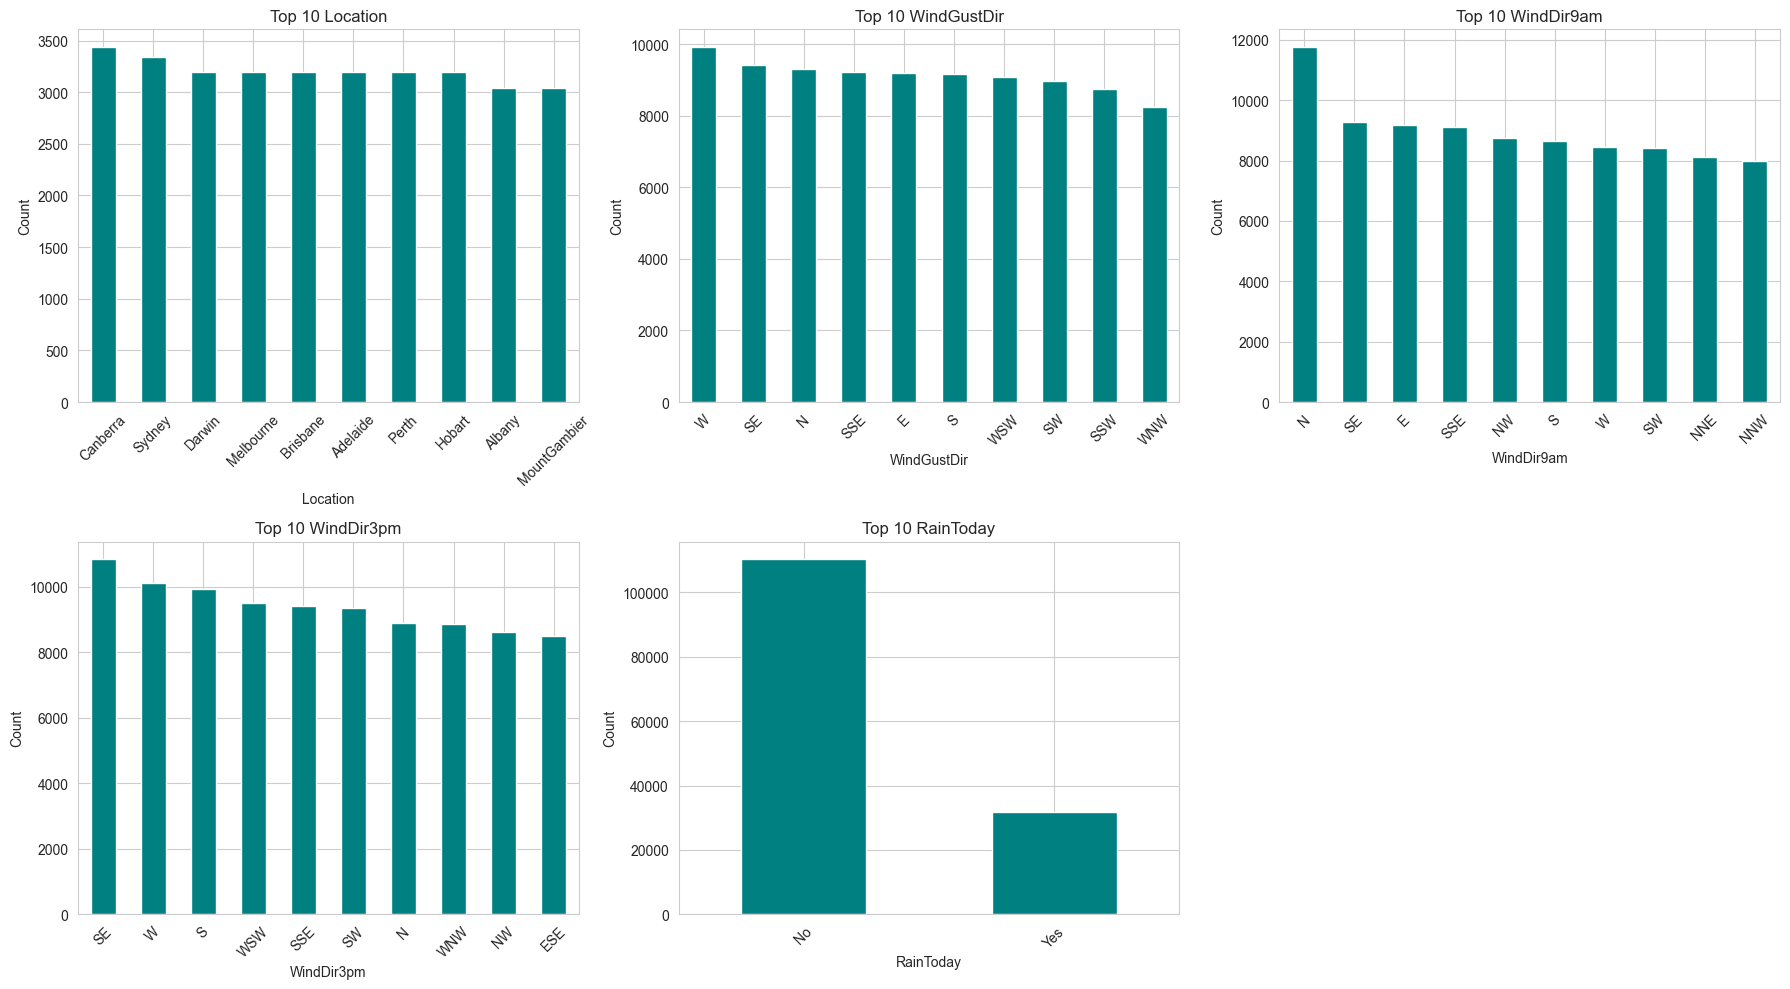

In [13]:
# Visualize key categorical features
cat_features = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
cat_features = [col for col in cat_features if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    if idx < len(axes):
        top_values = df[col].value_counts().head(10)
        top_values.plot(kind='bar', ax=axes[idx], color='teal')
        axes[idx].set_title(f'Top 10 {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(cat_features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

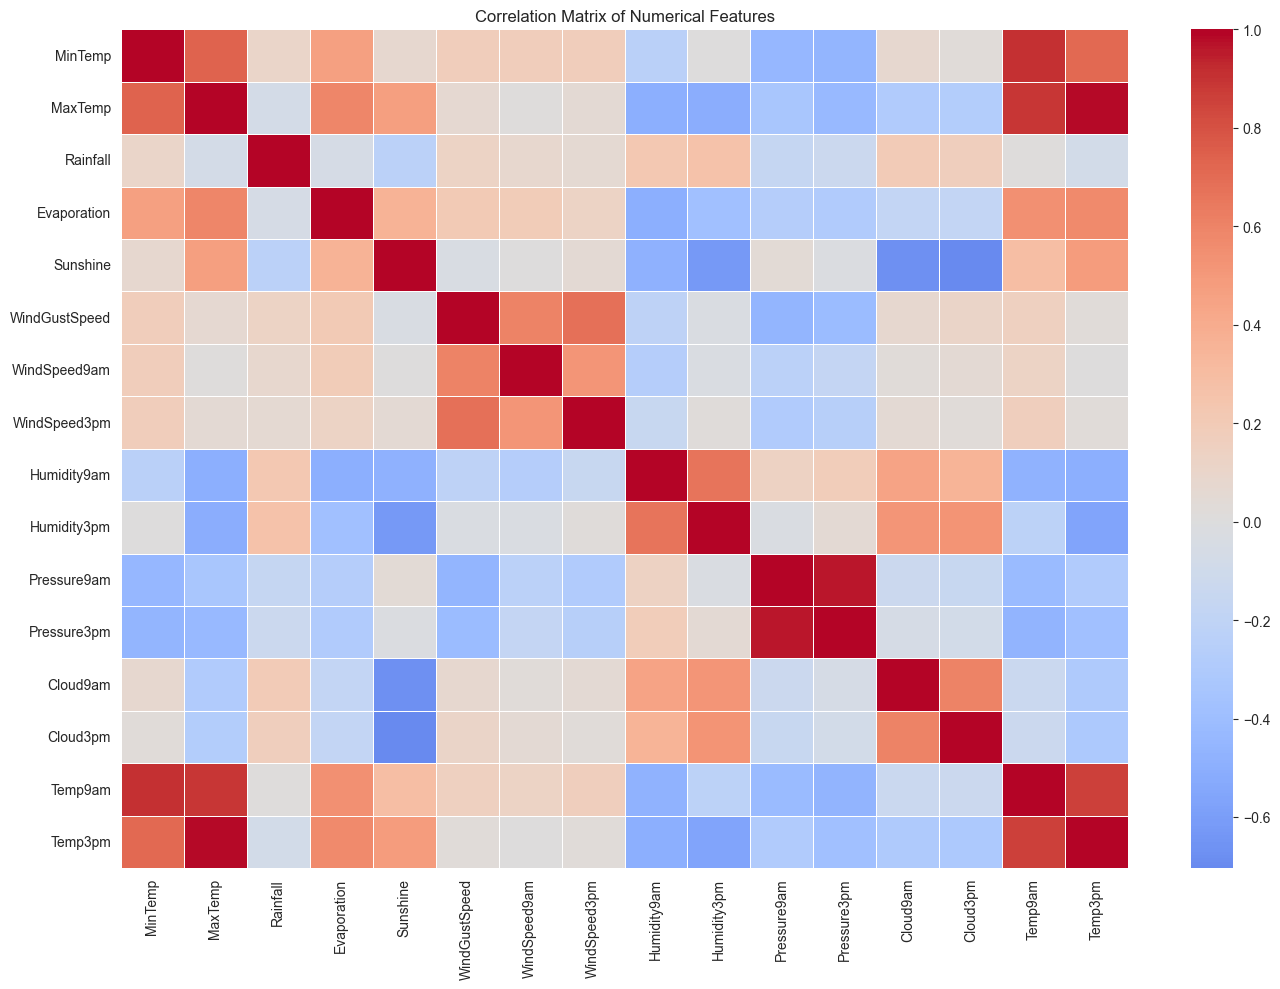

In [14]:
# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [15]:
# Find highly correlated features
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr:
    print("Highly correlated features (>0.8):")
    for feat1, feat2, corr in high_corr:
        print(f"{feat1} <-> {feat2}: {corr:.3f}")
else:
    print("No highly correlated features found (>0.8)")

Highly correlated features (>0.8):
MinTemp <-> Temp9am: 0.902
MaxTemp <-> Temp9am: 0.887
MaxTemp <-> Temp3pm: 0.985
Pressure9am <-> Pressure3pm: 0.961
Temp9am <-> Temp3pm: 0.861


## 7. Target vs Features Relationship

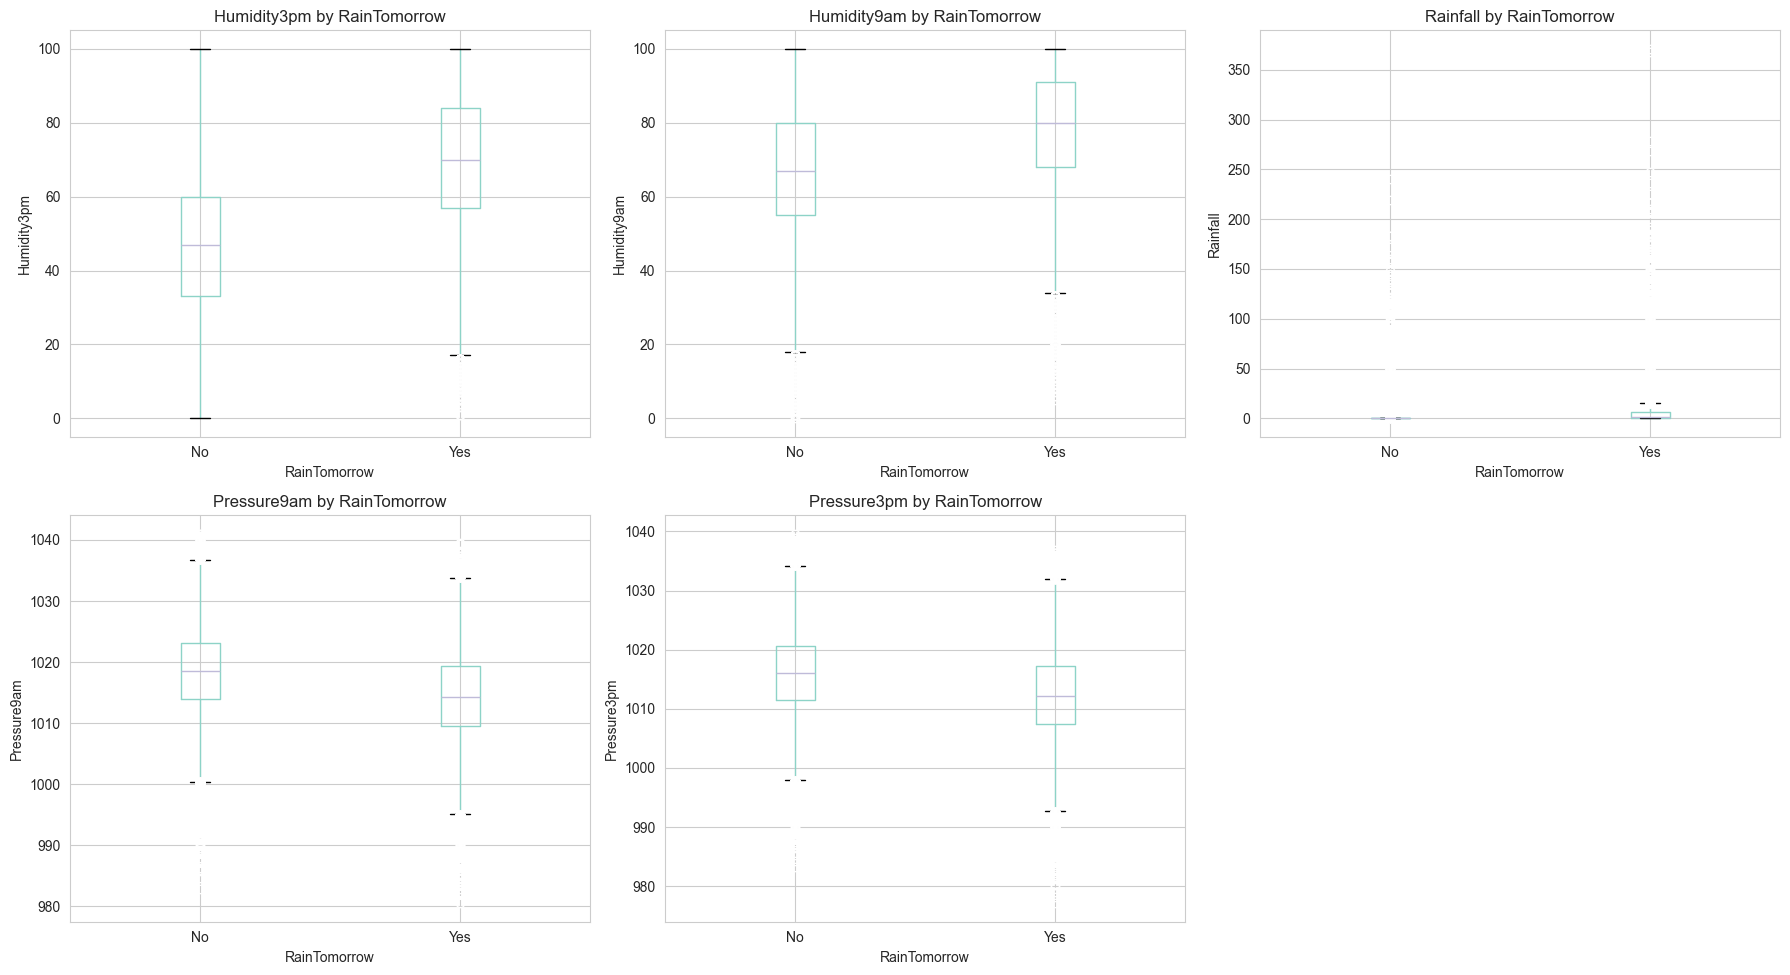

In [17]:
# Analyze numerical features vs target
if 'RainTomorrow' in df.columns:
    key_num_features = ['Humidity3pm', 'Humidity9am', 'Rainfall', 'Pressure9am', 'Pressure3pm']
    key_num_features = [col for col in key_num_features if col in df.columns]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(key_num_features):
        if idx < len(axes):
            df.boxplot(column=col, by='RainTomorrow', ax=axes[idx])
            axes[idx].set_title(f'{col} by RainTomorrow')
            axes[idx].set_xlabel('RainTomorrow')
            axes[idx].set_ylabel(col)
    
    # Hide unused subplots
    for idx in range(len(key_num_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('')
    plt.tight_layout()
    plt.show()